In [1]:
import Python_Scripts.QuantBacktester as qd
import pandas as pd
import numpy as np
from Python_Scripts.ST import *
import os

In [2]:
excelReaderfObj = qd.ExcelInputReader()
filePath = r"G:\.shortcut-targets-by-id\0B7f_UMMZHM_JNXljMVVXY2VPcHM\Investment Research_N\Manu\Universe\NiftyGold.xlsx"
closeDf = excelReaderfObj.getDataFrame(filePath, sheetName= 'Close')
closeDf.set_index('Date', inplace = True)

In [3]:
closeDf

,GBES.NS,NBES.NS
Date,,
2007-03-19,9.4780,36.979
2007-03-20,9.4239,37.252
2007-03-21,9.4567,37.969
2007-03-22,9.5015,39.003
2007-03-23,9.4718,39.019
...,...,...
2025-11-04,99.8000,289.590
2025-11-06,100.0700,288.240
2025-11-07,99.9400,288.440


In [4]:
universeFilePath = 'G:/.shortcut-targets-by-id/0B7f_UMMZHM_JNXljMVVXY2VPcHM/Investment Research_N/Manu/Universe/TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(excelFile= universeFilePath, sheetName = 'Sheet1', startDate = closeDf.index[0])
allTradingDatesDf.reset_index(drop = True, inplace = True)
monthEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby('YearMonth').Date.idxmax()]
monthEndDatesDf.sort_values(by=['Date'], inplace = True)


In [5]:
allTradingDatesDf

,Date,Month,Year,YearMonth
0,2007-03-19,3,2007,20073
1,2007-03-20,3,2007,20073
2,2007-03-21,3,2007,20073
3,2007-03-22,3,2007,20073
4,2007-03-23,3,2007,20073
...,...,...,...,...
4675,2026-01-30,1,2026,20261
4676,2026-02-01,2,2026,20262
4677,2026-02-02,2,2026,20262
4678,2026-02-03,2,2026,20262


In [6]:
monthEndDatesDf

,Date,Month,Year,YearMonth
8,2007-03-30,3,2007,20073
28,2007-04-30,4,2007,20074
49,2007-05-31,5,2007,20075
70,2007-06-29,6,2007,20076
92,2007-07-31,7,2007,20077
...,...,...,...,...
4614,2025-10-31,10,2025,202510
4633,2025-11-28,11,2025,202511
4655,2025-12-31,12,2025,202512
4675,2026-01-30,1,2026,20261


In [7]:
mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [8]:
closeMergedDf

,GBES.NS,NBES.NS
Date,,
2007-03-19,9.4780,36.979
2007-03-20,9.4239,37.252
2007-03-21,9.4567,37.969
2007-03-22,9.5015,39.003
2007-03-23,9.4718,39.019
...,...,...
2026-01-30,103.2900,290.820
2026-02-01,103.2900,290.820
2026-02-02,103.2900,290.820


In [9]:
closeMergedDf = closeMergedDf[closeMergedDf.index <= "2025-09-30"]
closeMergedDf

,GBES.NS,NBES.NS
Date,,
2007-03-19,9.4780,36.979
2007-03-20,9.4239,37.252
2007-03-21,9.4567,37.969
2007-03-22,9.5015,39.003
2007-03-23,9.4718,39.019
...,...,...
2025-09-24,94.6400,282.880
2025-09-25,94.4300,281.240
2025-09-26,94.2200,278.740


In [10]:
volFilePath = 'D:\Linear Model\smoothed_signal.xlsx'
calDf = excelReaderfObj.getDataFrameWithoutDate(volFilePath, sheetName= 'Sheet1')
calDf.set_index('RebalDate', inplace = True)

In [11]:
calDf

,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M,Observed_Vol_1M,VolBucket,Observed_VolBucket,Calibrated_VolBucket,CalibVol_Scaled,a_param,b_param,Vol_Regime_Monthly,Vol_Regime_Smooth
RebalDate,,,,,,,,,,,,,,
2020-01-03,0.010508,0.001210,0.002201,0.120436,-0.078286,0.008523,14,9,3.630640,0.281152,4.379757,-0.013399,0.194409,0.218635
2020-02-01,0.010688,-0.000086,0.002446,-0.094758,-0.558036,0.012903,15,19,4.311789,0.415667,7.301135,-0.035112,0.248814,0.238762
2020-03-06,0.014534,0.001125,0.005589,-0.121382,-0.301891,0.043536,22,30,3.638416,0.282688,8.622778,-0.039221,0.373096,0.309956
2020-04-03,0.016972,-0.000782,0.007106,-0.065731,-0.223139,0.020060,24,27,2.968577,0.126868,19.683180,-0.078820,0.461984,0.356471
2020-05-08,0.016028,0.000452,0.005795,0.149398,-0.132676,0.016468,23,24,4.431592,0.370574,16.775969,-0.057878,0.323440,0.333281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-02,0.009818,0.001069,0.002141,-0.206195,0.326644,0.011497,14,18,4.399475,0.090471,2.384968,0.043736,0.103135,0.167299
2025-06-06,0.010160,0.000990,0.002019,-0.298245,0.009285,0.006287,15,4,4.737240,0.131096,2.883864,0.033088,0.130357,0.146984
2025-07-04,0.010381,0.000635,0.002369,-0.105643,-0.037927,0.005184,15,2,4.331144,0.095018,1.784295,0.059121,0.093751,0.120911


In [12]:
calDf = calDf[calDf.index>='2020-02-01']
calDf

,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M,Observed_Vol_1M,VolBucket,Observed_VolBucket,Calibrated_VolBucket,CalibVol_Scaled,a_param,b_param,Vol_Regime_Monthly,Vol_Regime_Smooth
RebalDate,,,,,,,,,,,,,,
2020-02-01,0.010688,-0.000086,0.002446,-0.094758,-0.558036,0.012903,15,19,4.311789,0.415667,7.301135,-0.035112,0.248814,0.238762
2020-03-06,0.014534,0.001125,0.005589,-0.121382,-0.301891,0.043536,22,30,3.638416,0.282688,8.622778,-0.039221,0.373096,0.309956
2020-04-03,0.016972,-0.000782,0.007106,-0.065731,-0.223139,0.020060,24,27,2.968577,0.126868,19.683180,-0.078820,0.461984,0.356471
2020-05-08,0.016028,0.000452,0.005795,0.149398,-0.132676,0.016468,23,24,4.431592,0.370574,16.775969,-0.057878,0.323440,0.333281
2020-06-05,0.012933,-0.000355,0.003776,-0.139949,-0.662357,0.012078,19,17,5.720720,0.585314,16.293144,-0.055087,0.573578,0.448727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-02,0.009818,0.001069,0.002141,-0.206195,0.326644,0.011497,14,18,4.399475,0.090471,2.384968,0.043736,0.103135,0.167299
2025-06-06,0.010160,0.000990,0.002019,-0.298245,0.009285,0.006287,15,4,4.737240,0.131096,2.883864,0.033088,0.130357,0.146984
2025-07-04,0.010381,0.000635,0.002369,-0.105643,-0.037927,0.005184,15,2,4.331144,0.095018,1.784295,0.059121,0.093751,0.120911


In [13]:
calDf = calDf[['CalibVol_Scaled','Vol_Regime_Monthly','Vol_Regime_Smooth']]
calDf

,CalibVol_Scaled,Vol_Regime_Monthly,Vol_Regime_Smooth
RebalDate,,,
2020-02-01,0.415667,0.248814,0.238762
2020-03-06,0.282688,0.373096,0.309956
2020-04-03,0.126868,0.461984,0.356471
2020-05-08,0.370574,0.323440,0.333281
2020-06-05,0.585314,0.573578,0.448727
...,...,...,...
2025-05-02,0.090471,0.103135,0.167299
2025-06-06,0.131096,0.130357,0.146984
2025-07-04,0.095018,0.093751,0.120911


In [14]:
def getBins(x):
    if x <= 0.33:
        return 0.7
    elif x > 0.67:
        return 0.3
    else:
        return 0.5

In [15]:
eqWghSr_roll = calDf['Vol_Regime_Monthly'].apply(lambda x: getBins(x))
eqWghSr_ema = calDf['Vol_Regime_Smooth'].apply(lambda x: getBins(x))
eqWghSr = calDf['CalibVol_Scaled'].apply(lambda x: getBins(x))

In [16]:
eqWghSr_roll

RebalDate
2020-02-01    0.7
2020-03-06    0.5
2020-04-03    0.5
2020-05-08    0.7
2020-06-05    0.5
             ... 
2025-05-02    0.7
2025-06-06    0.7
2025-07-04    0.7
2025-08-01    0.5
2025-09-05    0.7
Name: Vol_Regime_Monthly, Length: 68, dtype: float64

In [17]:
weightDf_roll = pd.DataFrame(columns = closeMergedDf.columns, index = eqWghSr_roll.index)
weightDf_ema = pd.DataFrame(columns = closeMergedDf.columns, index = eqWghSr_ema.index)
weightDf = pd.DataFrame(columns=closeMergedDf.columns, index = eqWghSr.index)

In [18]:
weightDf_roll['NBES.NS'] = eqWghSr_roll
weightDf_roll['GBES.NS'] = 1- eqWghSr_roll

In [19]:
weightDf_roll

,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,0.3,0.7
2020-03-06,0.5,0.5
2020-04-03,0.5,0.5
2020-05-08,0.3,0.7
2020-06-05,0.5,0.5
...,...,...
2025-05-02,0.3,0.7
2025-06-06,0.3,0.7
2025-07-04,0.3,0.7


In [63]:
weightDf_roll.to_csv('D:/Linear Model/Weight_Df_Rolling.csv')
weightDf_ema.to_csv('D:/Linear Model/Weight_Df_EMA.csv')
weightDf.to_csv('D:/Linear Model/Weight_Df_CalibVol.csv')

In [20]:
weightDf_ema['NBES.NS'] = eqWghSr_ema
weightDf_ema['GBES.NS'] = 1- eqWghSr_ema

In [21]:
weightDf['NBES.NS'] = eqWghSr
weightDf['GBES.NS'] = 1- eqWghSr

In [22]:
diffDf_roll = weightDf_roll.diff(1)
diffDf_roll

,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,NaN,NaN
2020-03-06,0.2,-0.2
2020-04-03,0.0,0.0
2020-05-08,-0.2,0.2
2020-06-05,0.2,-0.2
...,...,...
2025-05-02,0.0,0.0
2025-06-06,0.0,0.0
2025-07-04,0.0,0.0


In [23]:
diffDf_ema = weightDf_ema.diff(1)
diffDf_ema

,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,NaN,NaN
2020-03-06,0.0,0.0
2020-04-03,0.2,-0.2
2020-05-08,0.0,0.0
2020-06-05,0.0,0.0
...,...,...
2025-05-02,0.0,0.0
2025-06-06,0.0,0.0
2025-07-04,0.0,0.0


In [24]:
diffDf = weightDf.diff()
diffDf

,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,NaN,NaN
2020-03-06,-0.2,0.2
2020-04-03,0.0,0.0
2020-05-08,0.2,-0.2
2020-06-05,0.0,0.0
...,...,...
2025-05-02,-0.2,0.2
2025-06-06,0.0,0.0
2025-07-04,0.0,0.0


In [25]:
actualwghDf_roll = weightDf_roll.loc[diffDf_roll[diffDf_roll['NBES.NS'] != 0].index]
actualwghDf_roll


,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,0.3,0.7
2020-03-06,0.5,0.5
2020-05-08,0.3,0.7
2020-06-05,0.5,0.5
2020-07-03,0.7,0.3
2020-08-07,0.5,0.5
2020-09-04,0.7,0.3
2023-05-05,0.5,0.5
2023-08-04,0.3,0.7


In [26]:
actualwghDf_ema = weightDf_ema.loc[diffDf_ema[diffDf_ema['NBES.NS'] != 0].index]
actualwghDf_ema

,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,0.3,0.7
2020-04-03,0.5,0.5
2020-10-01,0.7,0.3
2023-06-02,0.5,0.5
2023-09-01,0.3,0.7


In [27]:
actualwghDf = weightDf.loc[diffDf[diffDf['NBES.NS'] != 0].index]

In [28]:
rebalDates_roll = actualwghDf_roll.index
indexDates_roll = closeMergedDf.loc[rebalDates_roll[0]:].index

In [29]:
indexDates_roll

DatetimeIndex(['2020-02-01', '2020-02-03', '2020-02-04', '2020-02-05',
               '2020-02-06', '2020-02-07', '2020-02-10', '2020-02-11',
               '2020-02-12', '2020-02-13',
               ...
               '2025-09-17', '2025-09-18', '2025-09-19', '2025-09-22',
               '2025-09-23', '2025-09-24', '2025-09-25', '2025-09-26',
               '2025-09-29', '2025-09-30'],
              dtype='datetime64[ns]', name='Date', length=1407, freq=None)

In [30]:
rebalDates_ema = actualwghDf_ema.index
indexDates_ema = closeMergedDf.loc[rebalDates_ema[0]:].index

In [31]:
rebalDates = actualwghDf.index
indexDates = closeMergedDf.loc[rebalDates[0]:].index

In [32]:
indexObj_roll = qd.IndexCalculator(indexDates_roll.values, rebalDates_roll, actualwghDf_roll, closeMergedDf[actualwghDf_roll.columns])
simpleIndex_roll = indexObj_roll.getSimpleIndex(indexName='Simple_Index')

In [33]:
indexObj_ema = qd.IndexCalculator(indexDates_ema.values, rebalDates_ema, actualwghDf_ema, closeMergedDf[actualwghDf_ema.columns])
simpleIndex_ema = indexObj_ema.getSimpleIndex(indexName='Simple_Index')

In [34]:
indexObj = qd.IndexCalculator(indexDates.values, rebalDates, actualwghDf, closeMergedDf[actualwghDf.columns])
simpleIndex = indexObj.getSimpleIndex(indexName='Simple_Index')

In [35]:
actualwghDf

,GBES.NS,NBES.NS
RebalDate,,
2020-02-01,0.5,0.5
2020-03-06,0.3,0.7
2020-05-08,0.5,0.5
2020-07-03,0.7,0.3
2020-08-07,0.5,0.5
2020-10-01,0.7,0.3
2023-04-06,0.5,0.5
2023-07-07,0.3,0.7
2024-09-06,0.5,0.5


In [36]:
simpleIndex

(           Simple_Index
 Date                   
 2020-02-01        100.0
 2020-02-03    98.974527
 2020-02-04    99.430629
 2020-02-05    99.510353
 2020-02-06   100.291681
 ...                 ...
 2025-09-24   218.517646
 2025-09-25   217.652278
 2025-09-26   216.463666
 2025-09-29   218.380083
 2025-09-30   217.937427
 
 [1407 rows x 1 columns],
              GBES.NS   NBES.NS
 2020-02-01  1.393922  0.393174
 2020-02-03  1.393922  0.393174
 2020-02-04  1.393922  0.393174
 2020-02-05  1.393922  0.393174
 2020-02-06  1.393922  0.393174
 ...              ...       ...
 2025-09-24   1.18547  0.375865
 2025-09-25   1.18547  0.375865
 2025-09-26   1.18547  0.375865
 2025-09-29   1.18547  0.375865
 2025-09-30   1.18547  0.375865
 
 [1407 rows x 2 columns],
            TransactionCost
 RebalDate                 
 2020-02-01             NaN
 2020-03-06             NaN
 2020-05-08             NaN
 2020-07-03             NaN
 2020-08-07             NaN
 2020-10-01             NaN
 2023-04-06

In [37]:
simpleIndex_roll[0]

,Simple_Index
Date,
2020-02-01,100.0
2020-02-03,98.519732
2020-02-04,99.526271
2020-02-05,99.938971
2020-02-06,100.731744
...,...
2025-09-24,229.65446
2025-09-25,228.578957
2025-09-26,227.022683


<Axes: xlabel='Date'>

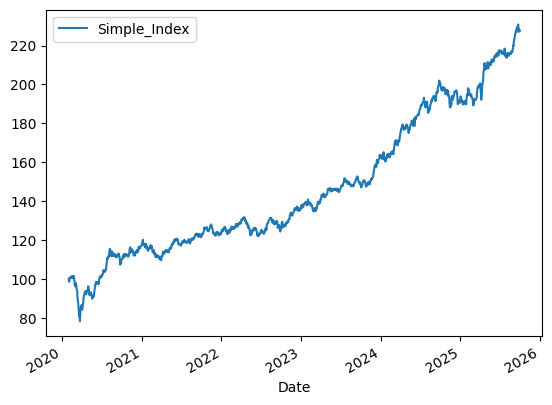

In [38]:
simpleIndex_roll[0].plot()

In [39]:
simpleIndex_ema[0]

,Simple_Index
Date,
2020-02-01,100.0
2020-02-03,98.519732
2020-02-04,99.526271
2020-02-05,99.938971
2020-02-06,100.731744
...,...
2025-09-24,202.772343
2025-09-25,201.871681
2025-09-26,200.588109


<Axes: xlabel='Date'>

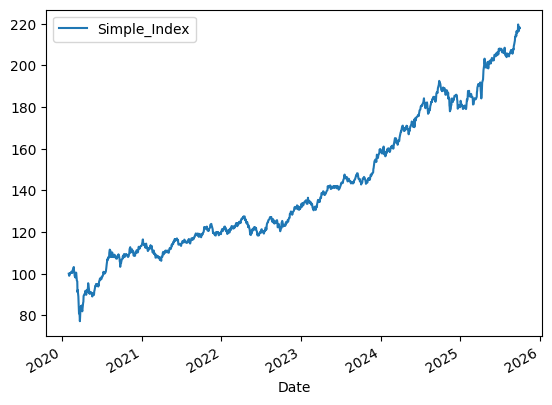

In [40]:
simpleIndex[0].plot()

<Axes: >

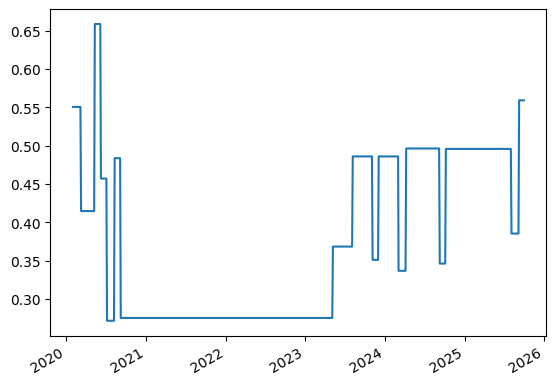

In [41]:
simpleIndex_roll[1]['NBES.NS'].plot()

<Axes: >

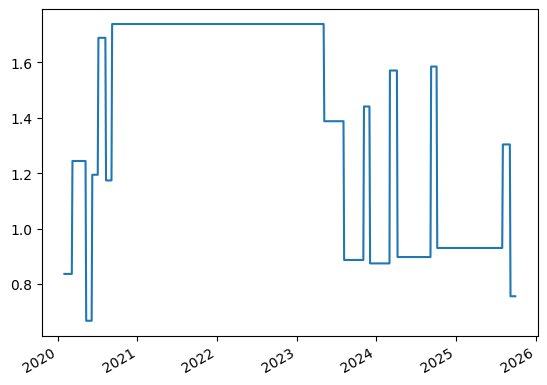

In [42]:
simpleIndex_roll[1]['GBES.NS'].plot()

In [43]:
df_1 = simpleIndex[0].rename(columns={'Simple_Index': 'Raw Signal'})
df_2 = simpleIndex_roll[0].rename(columns={'Simple_Index': 'Rolling MA Signal'})
df_3 = simpleIndex_ema[0].rename(columns={'Simple_Index': 'Exp MA Signal'})

In [44]:
benchmark_df = pd.read_csv('scid_Historical_Indices_2025_11_12.csv',parse_dates = ['_id.date'])
benchmark_df

,_id.scid,_id.date,index
0,SCET_0005,2025-11-11,910.467789
1,SCET_0005,2025-11-10,902.886205
2,SCET_0005,2025-11-07,895.357229
3,SCET_0005,2025-11-06,895.345863
4,SCET_0005,2025-11-04,897.280354
...,...,...,...
4518,SCET_0005,2007-07-05,100.270000
4519,SCET_0005,2007-07-04,101.000000
4520,SCET_0005,2007-07-03,100.890000
4521,SCET_0005,2007-07-02,100.240000


In [45]:
benchmark_df = benchmark_df.sort_values('_id.date')
benchmark_df.rename(columns = {'_id.date':'Date', 'index':'SCET_0005'}, inplace = True)
benchmark_df.set_index('Date', inplace = True)

In [46]:
benchmark_df = benchmark_df.drop('_id.scid',axis = 1)

In [47]:
benchmark_df = benchmark_df[benchmark_df.index>="2020-01-03"]
benchmark_df

,SCET_0005
Date,
2020-01-03,359.518684
2020-01-06,357.333026
2020-01-07,356.071538
2020-01-08,357.544240
2020-01-09,357.722009
...,...
2025-11-04,897.280354
2025-11-06,895.345863
2025-11-07,895.357229


In [48]:
comb1_df = df_1.merge(benchmark_df, on = 'Date', how = 'left')
comb1_df = comb1_df.merge(df_2, on = 'Date', how = 'left')
comb1_df = comb1_df.merge(df_3, on = 'Date', how = 'left')

In [49]:
comb1_df['SCET_0005'] = comb1_df['SCET_0005'].fillna(method='ffill')

In [50]:
comb1_df

,Raw Signal,SCET_0005,Rolling MA Signal,Exp MA Signal
Date,,,,
2020-02-01,100.0,352.145441,100.0,100.0
2020-02-03,98.974527,350.906432,98.519732,98.519732
2020-02-04,99.430629,354.373436,99.526271,99.526271
2020-02-05,99.510353,355.772152,99.938971,99.938971
2020-02-06,100.291681,358.592629,100.731744,100.731744
...,...,...,...,...
2025-09-24,218.517646,867.781734,229.65446,202.772343
2025-09-25,217.652278,863.786452,228.578957,201.871681
2025-09-26,216.463666,858.032841,227.022683,200.588109


In [51]:
comb1_df.isna().sum()

Raw Signal           0
SCET_0005            0
Rolling MA Signal    0
Exp MA Signal        0
dtype: int64

In [52]:
comb1_df['SCET_0005'] = comb1_df['SCET_0005']*100 / comb1_df['SCET_0005'][0]
comb1_df

,Raw Signal,SCET_0005,Rolling MA Signal,Exp MA Signal
Date,,,,
2020-02-01,100.0,100.000000,100.0,100.0
2020-02-03,98.974527,99.648154,98.519732,98.519732
2020-02-04,99.430629,100.632692,99.526271,99.526271
2020-02-05,99.510353,101.029890,99.938971,99.938971
2020-02-06,100.291681,101.830831,100.731744,100.731744
...,...,...,...,...
2025-09-24,218.517646,246.427082,229.65446,202.772343
2025-09-25,217.652278,245.292527,228.578957,201.871681
2025-09-26,216.463666,243.658654,227.022683,200.588109


In [64]:
comb1_df.to_csv('D:/Linear Model/Comparison_CalibVol_Rolling_EMA.csv')

<Axes: xlabel='Date'>

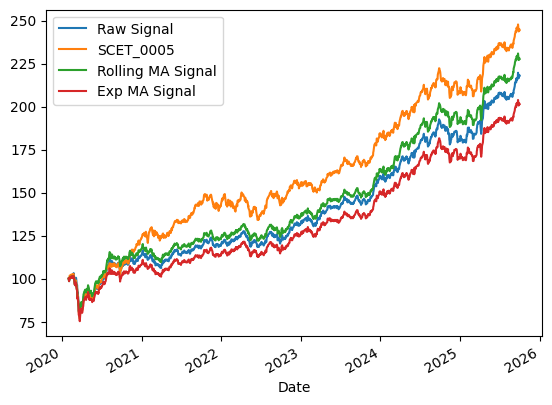

In [53]:
comb1_df.plot()

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def portfolio_metrics(portfolio_values: pd.Series, freq: str = 'D') -> dict:
    """
    Calculate portfolio standard deviation, CAGR, and maximum drawdown.
    """
    portfolio_values = portfolio_values.dropna()
    returns = portfolio_values.pct_change().dropna()
    ann_factor = {'D': 252, 'W': 52, 'M': 12}.get(freq.upper(), 252)

    # Annualized volatility
    stdev = returns.std() * np.sqrt(ann_factor)

    # CAGR
    final_value = portfolio_values.iloc[-1]
    n_obs = len(portfolio_values)
    cagr = (final_value / 100) ** (250 / n_obs) - 1

    # Drawdowns
    rolling_max = portfolio_values.cummax()
    drawdown = (portfolio_values / rolling_max) - 1
    max_drawdown = drawdown.min()

    return {
        'stdev': stdev,
        'CAGR': cagr,
        'max_drawdown': max_drawdown,
        'drawdown_series': drawdown
    }

# === Example usage with your DataFrame ===
# Assume your dataframe is called `df`
# and looks like: df.columns = ['Raw Signal', 'SCET_0005', 'Rolling MA Signal', 'Exp MA Signal']

metrics_table = pd.DataFrame(columns=['CAGR', 'Volatility', 'Max Drawdown'])

for col in comb1_df.columns:
    metrics = portfolio_metrics(comb1_df[col], freq='D')
    metrics_table.loc[col] = [
        f"{metrics['CAGR']:.2%}",
        f"{metrics['stdev']:.2%}",
        f"{metrics['max_drawdown']:.2%}"
    ]

print(metrics_table)


                     CAGR Volatility Max Drawdown
Raw Signal         14.85%     11.48%      -25.22%
SCET_0005          17.21%     12.09%      -25.53%
Rolling MA Signal  15.73%     10.88%      -22.95%
Exp MA Signal      13.24%     11.22%      -25.84%


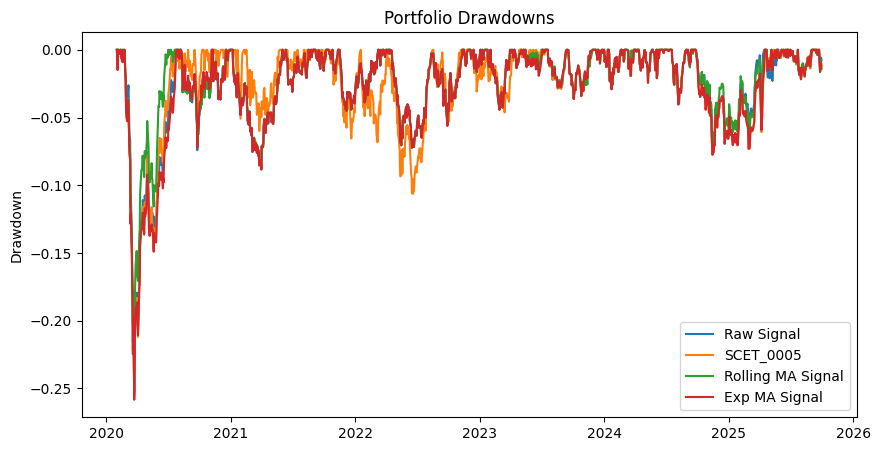

In [55]:
plt.figure(figsize=(10, 5))
for col in comb1_df.columns:
    dd = portfolio_metrics(comb1_df[col], freq='D')['drawdown_series']
    plt.plot(dd, label=col)

plt.title("Portfolio Drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.show()


In [56]:
calDf.index.name = 'Date'
calDf

,CalibVol_Scaled,Vol_Regime_Monthly,Vol_Regime_Smooth
Date,,,
2020-02-01,0.415667,0.248814,0.238762
2020-03-06,0.282688,0.373096,0.309956
2020-04-03,0.126868,0.461984,0.356471
2020-05-08,0.370574,0.323440,0.333281
2020-06-05,0.585314,0.573578,0.448727
...,...,...,...
2025-05-02,0.090471,0.103135,0.167299
2025-06-06,0.131096,0.130357,0.146984
2025-07-04,0.095018,0.093751,0.120911


In [57]:
weekly_signal = pd.read_excel('D:\Linear Model\Manu Weekly Signal.xlsx', parse_dates=['Date'], index_col='Date')
weekly_signal

,Signal
Date,
1995-11-03,NaN
1995-11-10,NaN
1995-11-17,NaN
1995-11-24,NaN
1995-12-01,NaN
...,...
2025-08-14,0.0
2025-08-22,0.0
2025-08-29,0.0


In [58]:
weekly_signal = weekly_signal[weekly_signal.index>="2020-01-01"]
weekly_signal

,Signal
Date,
2020-01-03,1.0
2020-01-10,1.0
2020-01-17,1.0
2020-01-24,1.0
2020-02-01,0.0
...,...
2025-08-14,0.0
2025-08-22,0.0
2025-08-29,0.0


In [59]:
signal_switch = []

for i in range(len(weekly_signal) - 1):
    curr_sig = weekly_signal['Signal'].iloc[i]
    next_sig = weekly_signal['Signal'].iloc[i + 1]

    if curr_sig != next_sig:
        signal_switch.append({
            'Date': weekly_signal.index[i + 1],
            'From_Signal': curr_sig,
            'To_Signal': next_sig
        })

signal_switch_df = pd.DataFrame(signal_switch)
print(signal_switch_df)


         Date  From_Signal  To_Signal
0  2020-02-01          1.0        0.0
1  2020-06-05          0.0        1.0
2  2021-01-29          1.0        0.0
3  2021-05-28          0.0        1.0
4  2021-11-26          1.0        0.0
5  2022-01-14          0.0        1.0
6  2022-02-25          1.0        0.0
7  2022-07-29          0.0        1.0
8  2022-12-23          1.0        0.0
9  2023-04-28          0.0        1.0
10 2023-10-27          1.0        0.0
11 2023-12-01          0.0        1.0
12 2024-10-18          1.0        0.0
13 2025-04-17          0.0        1.0
14 2025-08-08          1.0        0.0


In [60]:
merged = pd.merge_asof(
    signal_switch_df.sort_values('Date'),
    calDf.sort_index(),
    left_on='Date',
    right_index=True,
    direction='backward'
)

merged

,Date,From_Signal,To_Signal,CalibVol_Scaled,Vol_Regime_Monthly,Vol_Regime_Smooth
0,2020-02-01,1.0,0.0,0.415667,0.248814,0.238762
1,2020-06-05,0.0,1.0,0.585314,0.573578,0.448727
2,2021-01-29,1.0,0.0,0.891805,0.788152,0.757898
3,2021-05-28,0.0,1.0,0.970366,0.982048,0.929881
4,2021-11-26,1.0,0.0,0.763572,0.718151,0.765752
5,2022-01-14,0.0,1.0,0.934142,0.906648,0.848233
6,2022-02-25,1.0,0.0,0.917407,0.917538,0.880170
7,2022-07-29,0.0,1.0,0.871078,0.936305,0.954851
8,2022-12-23,1.0,0.0,0.868179,0.845079,0.836720
9,2023-04-28,0.0,1.0,0.657846,0.764690,0.765119


<Axes: xlabel='Date'>

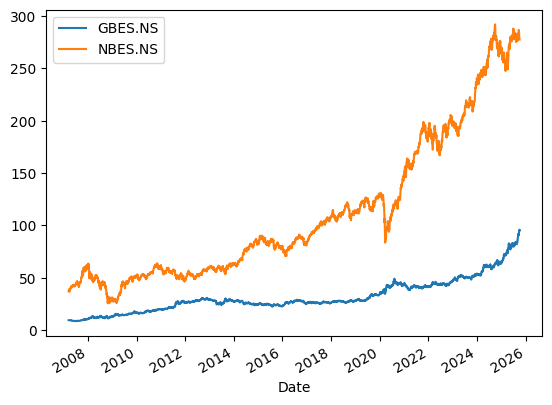

In [61]:
closeMergedDf.plot()

In [62]:
closeMergedDf.corr()

,GBES.NS,NBES.NS
GBES.NS,1.000000,0.931007
NBES.NS,0.931007,1.000000
